## Cálculo de CER

Cálculo del Character Error Rate por categorías de keywords usando alineación (jiwer) y distancia de Levenshtein.

In [ ]:
from tools.cer_utils import load_dataset, calculate_cer_from_dataframe

df = load_dataset('dataset_normalized.csv')
cer_df = calculate_cer_from_dataframe(df, 'keywords_full.json')


In [2]:
# gráfico de barras del CER global con intervalos de confianza

In [3]:
from tools.cer_analysis import CERAnalyzer, CERVisualizer

analyzer = CERAnalyzer(cer_df)
grouped = analyzer.get_grouped_by_provider_snr_category()
print(grouped)

   provider    snr                   category  edit_distance  ref_length  \
0    amazon    0dB  Datos Críticos (Num/Alfa)            177        1440   
1    amazon    0dB            Nombres Propios            886        4620   
2    amazon   10dB  Datos Críticos (Num/Alfa)             78        1440   
3    amazon   10dB            Nombres Propios            457        4620   
4    amazon    5dB  Datos Críticos (Num/Alfa)             86        1440   
5    amazon    5dB            Nombres Propios            521        4620   
6    amazon  clean  Datos Críticos (Num/Alfa)             46         480   
7    amazon  clean            Nombres Propios            149        1540   
8     azure    0dB  Datos Críticos (Num/Alfa)            190        1440   
9     azure    0dB            Nombres Propios            810        4620   
10    azure   10dB  Datos Críticos (Num/Alfa)              9        1440   
11    azure   10dB            Nombres Propios            243        4620   
12    azure 

In [4]:
global_grouped = analyzer.get_global_by_category()
CERVisualizer.display_global_by_category(global_grouped, title="Global CER by Category")


category,edit_distance,ref_length,cer,cer_pct
Datos Críticos (Num/Alfa),949,19200,0.049427,4.942708
Nombres Propios,6114,61600,0.099253,9.925325


In [5]:
cer_by_snr = analyzer.get_cer_by_snr_and_category()
CERVisualizer.display_cer_by_snr(cer_by_snr, title="Variación del CER por nivel de ruido")

snr,category,cer clean,cer 10db,cer 5db,cer 0db
,Datos Críticos (Num/Alfa),2.447917,1.753472,2.447917,11.458333
,Nombres Propios,4.107143,5.800866,7.716450,18.198052


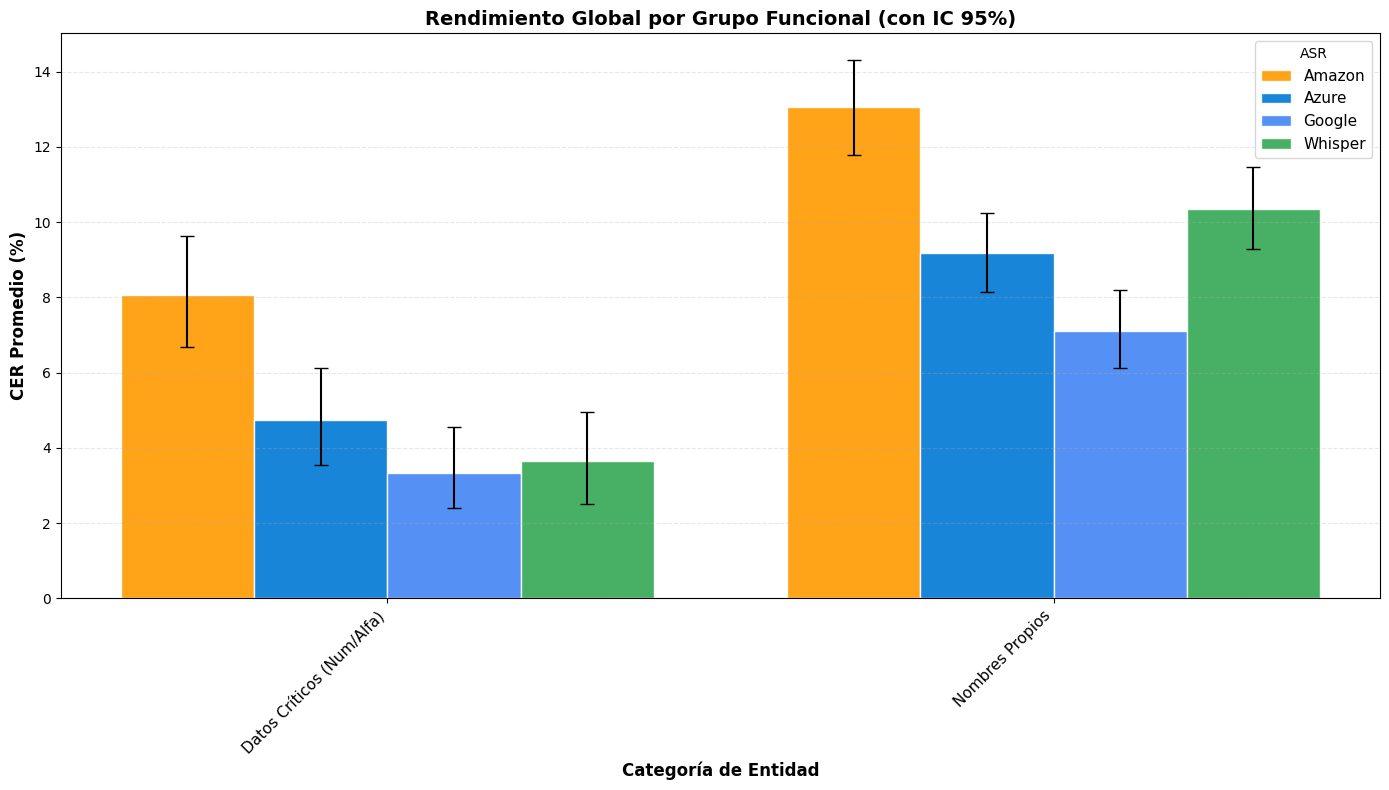

provider,amazon,azure,google,whisper
category,,,,
Datos Críticos (Num/Alfa),8.06% [6.69% - 9.64%] (N=1700),4.73% [3.55% - 6.12%] (N=1700),3.33% [2.40% - 4.55%] (N=1700),3.65% [2.51% - 4.96%] (N=1700)
Nombres Propios,13.07% [11.78% - 14.30%] (N=2400),9.18% [8.15% - 10.24%] (N=2400),7.12% [6.13% - 8.19%] (N=2400),10.34% [9.29% - 11.46%] (N=2400)


In [6]:
# 5.3.1. Rendimiento global por Grupo Funcional (Super-Categorías)
# Cálculo de estadísticas con intervalos de confianza (bootstrap)
cer_stats_ci = analyzer.get_cer_by_provider_and_category_with_ci()

# Gráfico de Barras Agrupadas con Barras de Error
CERVisualizer.plot_cer_by_category(cer_stats_ci, title="Rendimiento Global por Grupo Funcional (con IC 95%)")

# Tabla Complementaria: Matriz de Estadísticos Descriptivos
CERVisualizer.display_cer_statistics(cer_stats_ci, title="Estadísticas Descriptivas de CER por Grupo Funcional y ASR")

In [7]:
# Validación de Normalidad
# Seleccionamos un ejemplo representativo (e.g., Amazon - Producto) para validar la distribución
analyzer.check_normality(provider='amazon', category='Vocabulario de Negocio')

No hay datos para los filtros seleccionados.


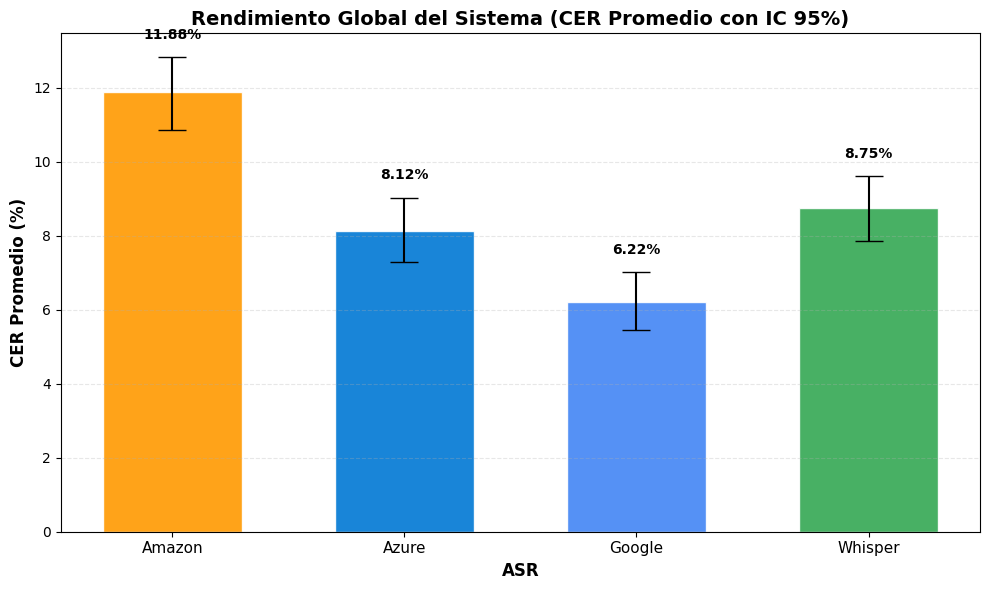

,provider,cer_pct,ci_lower_pct,ci_upper_pct,count
0,amazon,11.88,10.86,12.82,4100
1,azure,8.12,7.29,9.03,4100
2,google,6.22,5.45,7.01,4100
3,whisper,8.75,7.86,9.60,4100


In [8]:
# 5.3.4. Rendimiento Global del Sistema (Todos los grupos)
# Cálculo de CER global por proveedor (agregando todas las categorías)
global_cer_stats = analyzer.get_global_cer_by_provider_with_ci()

# Gráfico de Barras Global
CERVisualizer.plot_global_cer(global_cer_stats, title="Rendimiento Global del Sistema (CER Promedio con IC 95%)")

# Tabla de estadísticas globales
display(global_cer_stats[['provider', 'cer_pct', 'ci_lower_pct', 'ci_upper_pct', 'count']].round(2))